# 2026 Time Series Final Project

## Problem 1：ARIMA model and Kalman Filter

`Dataset-Stock.txt`，資料內容為 Alcoa 股票報酬率所計算出的日實現波動率。

在開始建立 local trend model 與 Kalman filter 之前，先對資料做基本檢查，包括：

1. 讀取資料並確認資料格式。
2. 檢查資料筆數與缺失值。
3. 計算描述統計量。
4. 繪製時間序列圖、直方圖與盒鬚圖，初步觀察資料分布與可能的極端值。

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

## 1. 讀取資料

由於 `Dataset-Stock.txt` 為單欄數值資料，且檔案中沒有欄名，因此讀取時需設定 `header=None`，再自行命名欄位。這裡將波動率欄位命名為 `rv`（realized volatility）。

In [2]:
stock_path = r"c:\Users\allen\OneDrive\Desktop\研究所\時序\Dataset-Stock.txt"

stock_df = pd.read_csv(stock_path, header=None, names=["rv"])
stock_df.head()

,rv
0,3.0692
1,6.7121
2,0.5711
3,2.1220
4,14.5181


## 2. 基本資料檢查

這一步先確認：

- 總共有多少筆觀測值。
- 是否存在缺失值。
- 欄位型態是否正確。
- 資料的大致集中位置與離散程度。

In [4]:
print("資料筆數：", stock_df.shape[0])
print("欄位數：", stock_df.shape[1])
print("缺失值個數：")
print(stock_df.isna().sum())
print("\n欄位型態：")
print(stock_df.dtypes)
print("\n描述統計量：")
print(stock_df.describe())

資料筆數： 340
欄位數： 1
缺失值個數：
rv    0
dtype: int64

欄位型態：
rv    float64
dtype: object

描述統計量：
               rv
count  340.000000
mean     2.872898
std      2.320472
min      0.266900
25%      1.520525
50%      2.333450
75%      3.432825
max     28.153400


### 基本檢查說明

從基本檢查可先確認此資料為單一數值型欄位，且沒有缺失值，因此可直接進入後續分析。描述統計量則有助於初步了解資料的平均數、中位數、標準差，以及是否可能存在明顯偏態或極端值。

## 3. 視覺化檢查

由於原始資料檔中只有波動率數值，沒有另外附日期欄，因此這裡先以觀測次序作為橫軸。這樣仍可用來觀察資料是否存在波動群聚、尖峰值，以及整體分布情形。

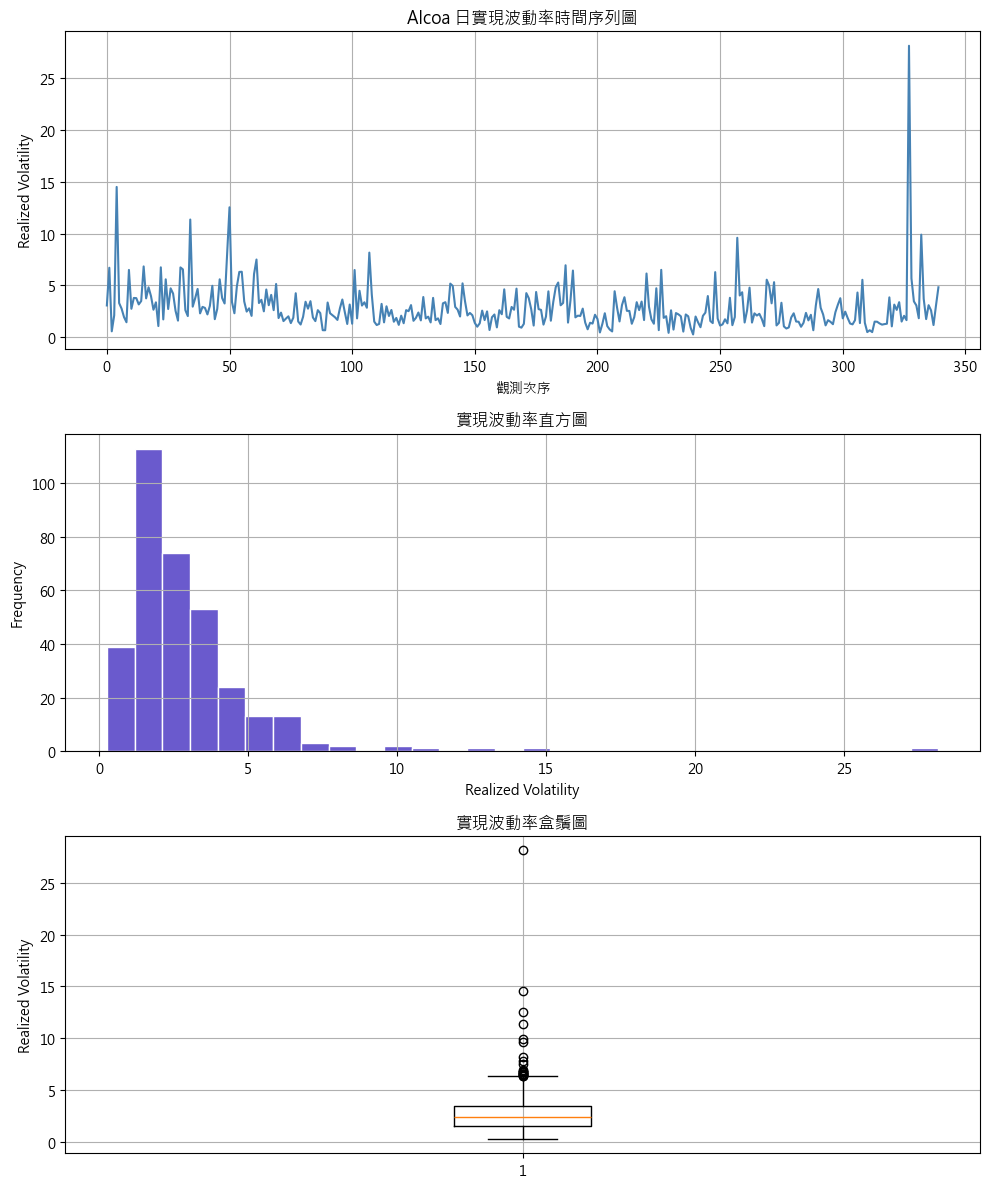

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(stock_df.index, stock_df["rv"], color="steelblue")
axes[0].set_title("Alcoa 日實現波動率時間序列圖")
axes[0].set_xlabel("觀測次序")
axes[0].set_ylabel("Realized Volatility")
axes[0].grid(True)

axes[1].hist(stock_df["rv"], bins=30, color="slateblue", edgecolor="white")
axes[1].set_title("實現波動率直方圖")
axes[1].set_xlabel("Realized Volatility")
axes[1].set_ylabel("Frequency")
axes[1].grid(True)

axes[2].boxplot(stock_df["rv"], vert=True)
axes[2].set_title("實現波動率盒鬚圖")
axes[2].set_ylabel("Realized Volatility")
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 視覺化說明

時間序列圖可用來觀察波動率是否有明顯的高低波動區段。直方圖可幫助判斷資料分布是否偏態，而盒鬚圖則有助於辨識極端值。這些初步觀察將作為後續建立 state-space model 與 Kalman filter 的參考。

## (a) 估計 local trend model

根據題目與投影片中的 Equations (11.1) 與 (11.2)，本題採用下列 local trend model：

$$y_t = \mu_t + e_t, \qquad e_t \sim N(0, \sigma_e^2)$$

$$\mu_{t+1} = \mu_t + \eta_t, \qquad \eta_t \sim N(0, \sigma_\eta^2)$$

其中，$y_t$ 為觀察到的實現波動率 $\mu_t$ 為不可觀測的潛在趨勢，$e_t$ 為觀測誤差，$\eta_t$ 為狀態誤差。

In [6]:
from statsmodels.tsa.statespace.structural import UnobservedComponents

local_trend_model = UnobservedComponents(stock_df["rv"], level="local level")
local_trend_result = local_trend_model.fit(disp=False)

print(local_trend_result.summary())
local_trend_result.params

                        Unobserved Components Results                         
Dep. Variable:                     rv   No. Observations:                  340
Model:                    local level   Log Likelihood                -761.211
Date:                Mon, 25 May 2026   AIC                           1526.422
Time:                        19:06:55   BIC                           1534.074
Sample:                             0   HQIC                          1529.472
                                - 340                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular     4.8951      0.135     36.130      0.000       4.630       5.161
sigma2.level         0.0166      0.015      1.138      0.255      -0.012       0.045
Ljung-Box (L1) (Q):         

sigma2.irregular    4.895144
sigma2.level        0.016628
dtype: float64

### (a) 結果說明

利用 local trend model 估計後，可得到觀測誤差變異數與狀態誤差變異數的估計值。根據目前的估計結果：

- $\sigma_e^2 = 4.8951$
- $\sigma_\eta^2 = 0.0166$

因此，估計後的模型可寫為：

$y_t = \mu_t + e_t, \qquad e_t \sim N(0, 4.8951)$

$\mu_{t+1} = \mu_t + \eta_t, \qquad \eta_t \sim N(0, 0.0166)$

由估計值可看出，觀測誤差的變異遠大於狀態誤差，表示資料中的短期波動相對明顯，而潛在趨勢本身隨時間變動得較為平滑。

## (b) Filtered variables 與 95% 信賴區間

filtered variable 指的是在觀測到第 `t` 期資料後，對當期潛在狀態的估計值。在 local trend model 中，潛在狀態為 $\mu_t$，因此 filtered variable 的數學表示為：

$\mu_{t|t} = E(\mu_t \mid y_1, y_2, \ldots, y_t)$

pointwise 95% confidence interval 可表示為：

$\mu_{t|t} \pm 1.96\sqrt{P_{t|t}}$

其中，$P_{t|t}$ 為 filtered state estimate 的變異數。

In [7]:
filtered_mean = pd.Series(local_trend_result.filtered_state[0], index=stock_df.index)
filtered_var = pd.Series(local_trend_result.filtered_state_cov[0, 0], index=stock_df.index)
filtered_se = np.sqrt(filtered_var)

filtered_df = pd.DataFrame({
    "rv": stock_df["rv"],
    "filtered_mean": filtered_mean,
    "filtered_lower": filtered_mean - 1.96 * filtered_se,
    "filtered_upper": filtered_mean + 1.96 * filtered_se
})

filtered_df.head()

,rv,filtered_mean,filtered_lower,filtered_upper
0,3.0692,3.069185,-1.267299,7.405669
1,6.7121,4.893726,1.824767,7.962686
2,0.5711,3.444722,0.933993,5.955451
3,2.1220,3.110130,0.929098,5.291162
4,14.5181,5.437878,3.479022,7.396735


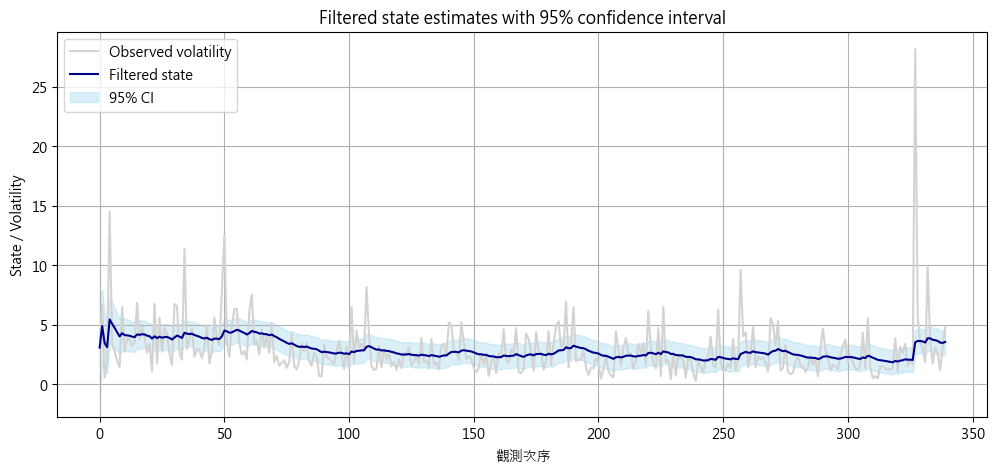

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(filtered_df.index, filtered_df["rv"], color="lightgray", label="Observed volatility")
plt.plot(filtered_df.index, filtered_df["filtered_mean"], color="darkblue", label="Filtered state")
plt.fill_between(
    filtered_df.index,
    filtered_df["filtered_lower"],
    filtered_df["filtered_upper"],
    color="skyblue",
    alpha=0.3,
    label="95% CI"
)
plt.title("Filtered state estimates with 95% confidence interval")
plt.xlabel("觀測次序")
plt.ylabel("State / Volatility")
plt.legend()
plt.grid(True)
plt.show()

### (b) 結果說明

此圖呈現 Kalman filter 對每一期潛在趨勢 $\mu_t$ 的 filtered estimate $\mu_{t|t}$。
表示在觀測到第 $t$ 期資料後，對當期狀態所做的即時估計。

由圖可見，filtered state 能夠追蹤波動率資料的整體變化方向，但相較於原始觀測值更為平滑，因為 Kalman filter 會同時考慮狀態演化方程與觀測誤差。圖中的陰影區域為 pointwise 95% confidence interval，用來表示各期 filtered estimate 的不確定性範圍。

## (c) Smoothed variables 與 95% 信賴區間

smoothed variable 指的是在使用完整樣本資訊 $y_1, y_2, \ldots, y_T$ 後，對第 $t$ 期潛在狀態的估計值。local trend model 中，smoothed variable 的數學表示為：

$\mu_{t|T} = E(\mu_t \mid y_1, y_2, \ldots, y_T)$

這和 filtered variable $\mu_{t|t}$ 的差別在於，smoothed estimate 不只使用當期以前的資訊，而是使用整段樣本資料回頭估計每一期的狀態。

其 pointwise 95% confidence interval 可表示為：

$\mu_{t|T} \pm 1.96\sqrt{P_{t|T}}$

其中，$P_{t|T}$ 為 smoothed state estimate 的變異數。

In [9]:
smoothed_mean = pd.Series(local_trend_result.smoothed_state[0], index=stock_df.index)
smoothed_var = pd.Series(local_trend_result.smoothed_state_cov[0, 0], index=stock_df.index)
smoothed_se = np.sqrt(smoothed_var)

smoothed_df = pd.DataFrame({
    "rv": stock_df["rv"],
    "smoothed_mean": smoothed_mean,
    "smoothed_lower": smoothed_mean - 1.96 * smoothed_se,
    "smoothed_upper": smoothed_mean + 1.96 * smoothed_se
})

smoothed_df.head()

,rv,smoothed_mean,smoothed_lower,smoothed_upper
0,3.0692,4.072538,3.040777,5.104300
1,6.7121,4.075947,3.072113,5.079780
2,0.5711,4.070400,3.092093,5.048708
3,2.1220,4.076741,3.121724,5.031757
4,14.5181,4.089721,3.155922,5.023519


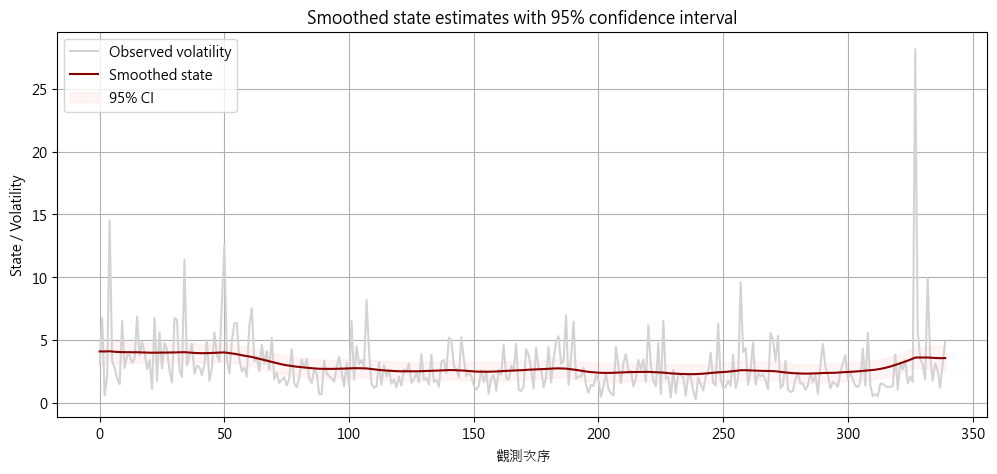

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(smoothed_df.index, smoothed_df["rv"], color="lightgray", label="Observed volatility")
plt.plot(smoothed_df.index, smoothed_df["smoothed_mean"], color="darkred", label="Smoothed state")
plt.fill_between(
    smoothed_df.index,
    smoothed_df["smoothed_lower"],
    smoothed_df["smoothed_upper"],
    color="mistyrose",
    alpha=0.4,
    label="95% CI"
)
plt.title("Smoothed state estimates with 95% confidence interval")
plt.xlabel("觀測次序")
plt.ylabel("State / Volatility")
plt.legend()
plt.grid(True)
plt.show()

### (c) 結果說明

此圖呈現 smoothed state estimate，也就是 $\mu_{t|T}$。它表示：在使用完整樣本資料後，回頭對每一期潛在趨勢所做的估計。

由於 smoothed estimate 使用了全樣本資訊，因此相較於 filtered estimate，通常會更平滑，也更能呈現整體趨勢變化。圖中的陰影區域為 pointwise 95% confidence interval，用來表示各期 smoothed estimate 的不確定性範圍。